In [15]:
# !pip list | grep qiskit
# !pip install --upgrade pip
# !pip uninstall qiskit -y
# !pip uninstall qiskit qiskit-aer qiskit-ibmq-provider qiskit-terra -y
# !rm -rf /opt/homebrew/lib/python3.10/site-packages/qiskit
# !pip list | grep qiskit
# !conda remove -n qiskit_env --all
# !pip install qiskit-terra
# !pip install qiskit-aer
# !pip install qiskit-ibmq-provider
# !pip install qiskit-terra==0.46.3 
# !pip install qiskit-ibmq-provider==0.20.2
# !pip install qiskit-aer==0.17.2
# !pip install -U qiskit
# !pip install 'qiskit[visualization]'
# !pip install numpy
# !pip install matplotlib


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
# from qiskit_aer import AerSimulator
# from qiskit.visualization import plot_histogram

In [23]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())

{'11': 509, '00': 515}


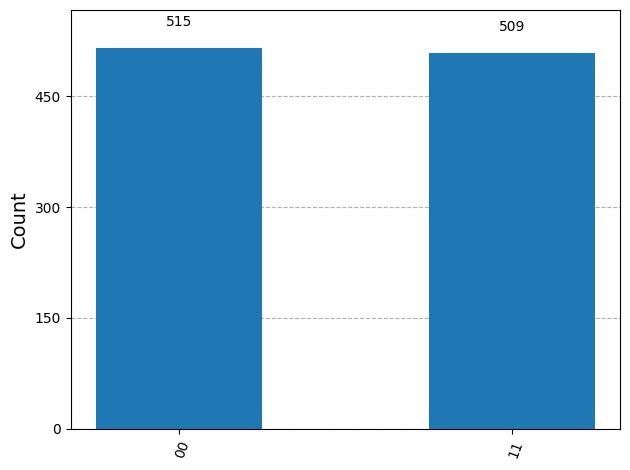

In [25]:
counts = result[0].data.meas.get_counts()
plot_histogram(counts)

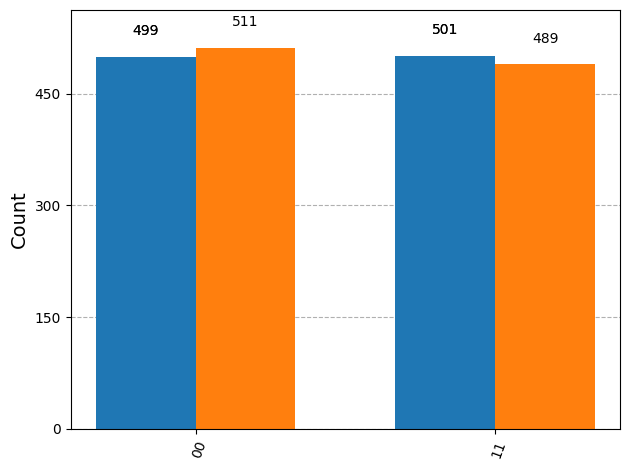

In [20]:
counts1 = {'00': 499, '11': 501}
counts2 = {'00': 511, '11': 489}

data = [counts1, counts2]
plot_histogram(data)

In [6]:
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure([0, 1], [0, 1])

In [26]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import LieTrotter
from qiskit.circuit.library import PauliEvolutionGate

In [27]:
hamiltonian = SparsePauliOp.from_list([
    ("ZZ", 1.0),
    ("XI", 0.5)
])

In [33]:
#### Hamiltonian 

def pauli_string(N, ops):
    """
    N: number of qubits
    ops: dict like {qubit_index: 'X'/'Y'/'Z'}
    """
    s = ["I"] * N
    for qubit, op in ops.items():
        s[qubit] = op
    return "".join(s)


def build_J(N, a):
    
    positions = list(range(N)) 
    J = {}

    for i in range(N):
        for j in range(i + 1, N):
            dist = abs(positions[i] - positions[j])
            d_pbc = min(dist, N - dist)   # 🔥 key line for PBC
            J[(i, j)] = 1.0 / (d_pbc ** a)

    return J


terms = []

# X fields
N=4
h=2.0
a=1.8
J=build_J(N, a)
for i in range(N):
    terms.append((pauli_string(N, {i: "X"}), h))

# ZZ interactions
for (i, j), val in J.items():
    terms.append((pauli_string(N, {i: "Z", j: "Z"}), val))
    
print(terms)    

[('XIII', 2.0), ('IXII', 2.0), ('IIXI', 2.0), ('IIIX', 2.0), ('ZZII', 1.0), ('ZIZI', 0.2871745887492588), ('ZIIZ', 1.0), ('IZZI', 1.0), ('IZIZ', 0.2871745887492588), ('IIZZ', 1.0)]


In [40]:
hamiltonian = SparsePauliOp.from_list(terms)
time = 1.0
trotter = LieTrotter(reps=2)

In [43]:
##building evolution gate
evolution_gate = PauliEvolutionGate(
    hamiltonian,
    time=time,
    synthesis=trotter
)
# print(evolution_gate)
print(evolution_gate.operator)

SparsePauliOp(['XIII', 'IXII', 'IIXI', 'IIIX', 'ZZII', 'ZIZI', 'ZIIZ', 'IZZI', 'IZIZ', 'IIZZ'],
              coeffs=[2.        +0.j, 2.        +0.j, 2.        +0.j, 2.        +0.j,
 1.        +0.j, 0.28717459+0.j, 1.        +0.j, 1.        +0.j,
 0.28717459+0.j, 1.        +0.j])


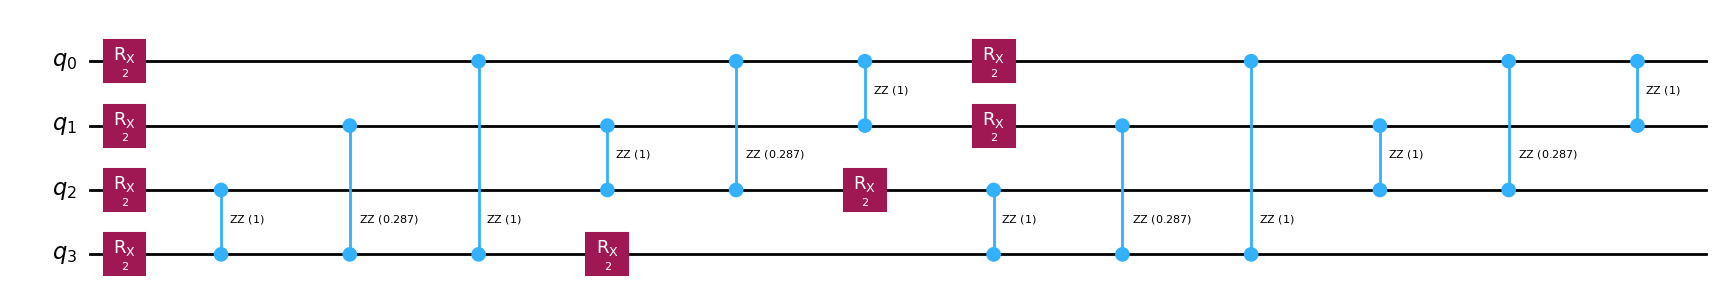

In [ ]:
## application of the circuit to qbits  and visualization##
qc = QuantumCircuit(N)
qc.append(evolution_gate, list(range(N)))

qc.decompose().draw("mpl")